# Adaptive Multimodal Biometric Identification — Reproducibility Notebook

Lightweight CNN with confidence-based score fusion on the MULBv1 dataset.
Reproduces every table and figure from the trained models (inference only;
set `TRAIN = True` to retrain).

Clean evaluation: 505 matched face-hand test pairs / 342 validation pairs,
spanning 173 of 176 subjects after SHA-256 leakage exclusion.

## Requirements
- Python 3.10+, TensorFlow 2.x, scikit-learn, OpenCV, matplotlib, scipy
- Google Drive: trained .keras models, exclude_list.csv, history JSONs, split folders

## Runtime note (Table 6)
CPU latencies are produced by the separate script benchmark_runtime.py, run
locally on the target CPU (Intel Core i7-8650U). The TFLite cell here reports
Colab-server timings, not the paper hardware.

## 1. Setup and Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob as gb
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_curve, auc, confusion_matrix)
from sklearn.preprocessing import label_binarize
from scipy.spatial.distance import cdist

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
# ============================================================
# Configuration — change TRAIN to True to retrain from scratch
# ============================================================
TRAIN = False

FACE_MODEL_PATH = '/content/drive/MyDrive/face_model_final_fixedfeb.keras'
HAND_MODEL_PATH = '/content/drive/MyDrive/hand_model_final_v2.keras'

FACE_TRAIN_DIR = '/content/drive/MyDrive/split faces/train'
FACE_VAL_DIR   = '/content/drive/MyDrive/split faces/val'
FACE_TEST_DIR  = '/content/drive/MyDrive/split faces/test'

HAND_TRAIN_DIR = '/content/drive/MyDrive/final split hand/train'
HAND_VAL_DIR   = '/content/drive/MyDrive/final split hand/val'
HAND_TEST_DIR  = '/content/drive/MyDrive/final split hand/test'

IMG_SIZE  = 200
N_CLASSES = 176
THRESHOLD = 0.95
EPOCHS    = 100
BATCH     = 32
LR        = 0.001

In [ ]:
Code = {
    'abas ahmed':0, 'abas hamad':1, 'abas mohamad':2, 'abdalah omran':3, 'abdalah salah':4, 'abdalah salh':5,
    'abdalrahman husan':6, 'abeer raad':7, 'ahmed aeid':8, 'ahmed eemad':9, 'ahmed emad':10, 'ahmed fras':11,
    'ahmed hamed':12, 'ahmed kasem':13, 'ahmed obead':14, 'alaa salam':15, 'alhasan ali':16, 'ali fadhel':17,
    'ali faesel':18, 'ali fras':19, 'ali gazi':20, 'ali jasem':21, 'ali jaza':22, 'ali kadhim':23,
    'ali kaled':24, 'ali kareem':25, 'ali mofak':26, 'ali mohamad':27, 'ali mohamad k':28, 'ali mohamad s':29,
    'ali moraa':30, 'ali najah':31, 'ali radi':32, 'ali rahi':33, 'ali saad':34, 'ali sahb':35,
    'ali wafee':36, 'ali yusaf':37, 'ameer basem':38, 'anwer ali':39, 'anwer redha':40, 'atheer saad':41,
    'aws salem':42, 'aya jaseem':43, 'aya jeid':44, 'ayat hussen':45, 'banen ahmed':46, 'banen hasan':47,
    'banen kalaf':48, 'esa badar':49, 'esam salam':50, 'fatma atea':51, 'fatma atheer':52, 'fatma dyaa':53,
    'fatma emad':54, 'fatma jodat':55, 'fatma kadhim':56, 'fatma kaun':57, 'fatma sadk':58, 'fatma salam':59,
    'fras':60, 'furkan tufek':61, 'gadeer mohamad':62, 'gaeth kamel':63, 'gafer mohamed':64, 'gufran mohamad':65,
    'habebe malak':66, 'hamsa':67, 'hamza ali':68, 'hasan alaa':69, 'hasan emad':70, 'hasan mohamed':71,
    'heba mahmood':72, 'hesham kadhim':73, 'huda falah':74, 'humam najah':75, 'husan ahmed':76, 'husan ali':77,
    'husan fras':78, 'husan mahdi':79, 'husan razak':80, 'husan shaker':81, 'hyder malk':82, 'ibrahem hamed':83,
    'iklas salh':84, 'ilaf ashor':85, 'kadega salam':86, 'kader malk':87, 'kadhim hashem':88, 'kadhim mohamad':89,
    'kadhim salam':90, 'kaher musa':91, 'kaled rasheed':92, 'karar ali':93, 'karar naser':94, 'kasem mohamad':95,
    'kasem mohamad t':96, 'manar aed':97, 'mansor husan':98, 'maream mahmood':99, 'maream thamer':100,
    'marwa kaled':101, 'mazen hamad':102, 'mohamad abdalhaleem':103, 'mohamad aimer':104, 'mohamad ameen':105,
    'mohamad baker':106, 'mohamad basem':107, 'mohamad emad':108, 'mohamad kaes':109, 'mohamad kaleel':110,
    'mohamad kareem':111, 'mohamad kasem':112, 'mohamad latef':113, 'mohamad saad':114, 'mohamad salah':115,
    'mugtba hasan':116, 'mugtba mohamad':117, 'muheman majeed':118, 'muktada ali':119, 'muntadher salah':120,
    'murad kadhim':121, 'murtdh esam':122, 'murtdh leath':123, 'murtdh omran':124, 'mustafa ali':125,
    'mustafa fathel':126, 'mustafa fawaz':127, 'mustafa husan':128, 'mustafa mahmood':129, 'mustafa wleed':130,
    'nabaa mohamad':131, 'naors ali':132, 'nbras mahmood':133, 'noor hasan':134, 'noor mohamad':135,
    'rafeef kareem':136, 'ranyi mohamad':137, 'rawaa kaes':138, 'reem rashed':139, 'rehab hson':140,
    'roua jaber':141, 'sabah hyder':142, 'sadak abdalkadham':143, 'saef emad':144, 'saja abdalnabi':145,
    'sajad hyder':146, 'sajad ismaeel':147, 'sajad musa':148, 'sameer ahmed':149, 'sawsan kasem':150,
    'shaemaa abdalha':151, 'shahliaa fahem':152, 'shereen salah':153, 'tabark salem':154, 'teba hasan':155,
    'thofukar jasem':156, 'waaim abdalsalam':157, 'walaa aamer':158, 'walaa hasan':159, 'waleed rasheed':160,
    'wedad turki':161, 'wesam':162, 'wesam mohamad':163, 'yaser amar':164, 'yaser muaed':165,
    'yasmeen husan':166, 'zahraa ahmed':167, 'zahraa mohamad':168, 'zahraa ryad':169, 'zaid husan':170,
    'zaid jafar':171, 'zaidan jamal':172, 'zainab afar':173, 'zainab ali':174, 'zainab jaber':175
}
print(f"Total subjects: {len(Code)}")

Total subjects: 176


In [ ]:
import csv

# ---- Load the leakage-exclusion list produced by the diagnostic notebook ----
# exclude_list.csv columns: modality, split, subject, filename
# (these are the val/test images that are byte-identical SHA-256 duplicates of
#  training images; removing them eliminates the data leakage.)
EXCLUDE_CSV = '/content/drive/MyDrive/exclude_list.csv'
EXCLUDE = set()
with open(EXCLUDE_CSV, encoding='utf-8') as f:
    for r in csv.DictReader(f):
        EXCLUDE.add((r['modality'], r['split'],
                     r['subject'].lower().strip(), r['filename']))
print(f"Exclusion list loaded: {len(EXCLUDE)} leaked val/test files will be skipped.")


def load_images(path, label_dict, modality=None, split=None, max_per_subject=None):
    """Load pre-processed images: grayscale, resize to 200x200, normalize to [0,1].
    When modality and split are supplied, any file listed in exclude_list.csv is
    skipped, so the returned val/test sets contain no train-leaked duplicates."""
    images, labels = [], []
    for folder in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder)
        if not os.path.isdir(folder_path):
            continue
        key = folder.lower().strip()
        if key not in label_dict:
            print(f"Warning: '{key}' not in subject list, skipping.")
            continue
        files = sorted(gb.glob(os.path.join(folder_path, '*.jpg')))
        if modality is not None and split is not None:
            files = [f for f in files
                     if (modality, split, key, os.path.basename(f)) not in EXCLUDE]
        if max_per_subject:
            files = files[:max_per_subject]
        for img_file in files:
            img = cv2.imread(img_file)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = img.astype(np.float32) / 255.0
            images.append(img)
            labels.append(label_dict[key])
    return np.array(images), np.array(labels)

# Load face data  (train unfiltered; val/test cleaned via the exclusion list)
print("Loading face images...")
x_face_train, y_face_train = load_images(FACE_TRAIN_DIR, Code)
x_face_val,   y_face_val   = load_images(FACE_VAL_DIR,   Code, modality='face', split='val')
x_face_test,  y_face_test  = load_images(FACE_TEST_DIR,  Code, modality='face', split='test')

# Load hand data
print("Loading hand images...")
x_hand_train, y_hand_train = load_images(HAND_TRAIN_DIR, Code)
x_hand_val,   y_hand_val   = load_images(HAND_VAL_DIR,   Code, modality='hand', split='val')
x_hand_test,  y_hand_test  = load_images(HAND_TEST_DIR,  Code, modality='hand', split='test')

# Expand dims for CNN input
x_face_train = np.expand_dims(x_face_train, -1)
x_face_val   = np.expand_dims(x_face_val,   -1)
x_face_test  = np.expand_dims(x_face_test,  -1)
x_hand_train = np.expand_dims(x_hand_train, -1)
x_hand_val   = np.expand_dims(x_hand_val,   -1)
x_hand_test  = np.expand_dims(x_hand_test,  -1)

from tensorflow.keras.utils import to_categorical
y_face_train_ = to_categorical(y_face_train, N_CLASSES)
y_face_val_   = to_categorical(y_face_val,   N_CLASSES)
y_hand_train_ = to_categorical(y_hand_train, N_CLASSES)
y_hand_val_   = to_categorical(y_hand_val,   N_CLASSES)

print(f"Face  - train: {x_face_train.shape}, val: {x_face_val.shape}, test: {x_face_test.shape}")
print(f"Hand  - train: {x_hand_train.shape}, val: {x_hand_val.shape}, test: {x_hand_test.shape}")


Exclusion list loaded: 45 leaked val/test files will be skipped.
Loading face images...
Loading hand images...
Face  - train: (2465, 200, 200, 1), val: (516, 200, 200, 1), test: (521, 200, 200, 1)
Hand  - train: (2824, 200, 200, 1), val: (344, 200, 200, 1), test: (511, 200, 200, 1)


In [ ]:
def build_model(n_classes=176):
    """Lightweight CNN: 3 conv blocks + 2 FC layers + softmax output.
    592,776 parameters — shared architecture for both face and hand.
    """
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='leaky_relu',
                               input_shape=(IMG_SIZE, IMG_SIZE, 1)),
        tf.keras.layers.MaxPool2D(4, 4),
        tf.keras.layers.Conv2D(16, (3,3), activation='leaky_relu'),
        tf.keras.layers.MaxPool2D(2, 2),
        tf.keras.layers.Conv2D(8,  (3,3), activation='leaky_relu'),
        tf.keras.layers.MaxPool2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='leaky_relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='leaky_relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

if TRAIN:
    face_model = build_model()
    hand_model = build_model()
    face_model.summary()
    print(f"Total parameters: {face_model.count_params():,}")
else:
    face_model = tf.keras.models.load_model(FACE_MODEL_PATH, compile=False)
    hand_model = tf.keras.models.load_model(HAND_MODEL_PATH, compile=False)
    face_model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                       loss='categorical_crossentropy', metrics=['accuracy'])
    hand_model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                       loss='categorical_crossentropy', metrics=['accuracy'])
    print(f"Models loaded. Parameters: {face_model.count_params():,}")

Models loaded. Parameters: 592,776


In [ ]:
if TRAIN:
    print("Training face model...")
    face_history = face_model.fit(
        x_face_train, y_face_train_,
        epochs=EPOCHS, batch_size=BATCH,
        validation_data=(x_face_val, y_face_val_),
        verbose=1
    )
    face_model.save(FACE_MODEL_PATH)
    with open('/content/drive/MyDrive/history_face.json', 'w') as f:
        json.dump({k: [float(v) for v in vals]
                   for k, vals in face_history.history.items()}, f)

    print("\nTraining hand model...")
    hand_history = hand_model.fit(
        x_hand_train, y_hand_train_,
        epochs=EPOCHS, batch_size=BATCH,
        validation_data=(x_hand_val, y_hand_val_),
        verbose=1
    )
    hand_model.save(HAND_MODEL_PATH)
    with open('/content/drive/MyDrive/history_palm_v2.json', 'w') as f:
        json.dump({k: [float(v) for v in vals]
                   for k, vals in hand_history.history.items()}, f)
    print("Models saved.")
else:
    print("TRAIN = False — skipping training, loading saved models.")

TRAIN = False — skipping training, loading saved models.


## 2. Inference and Adaptive Fusion

In [ ]:
# Run inference on the cleaned test sets
face_all = face_model.predict(x_face_test, batch_size=32, verbose=1)
hand_all = hand_model.predict(x_hand_test, batch_size=32, verbose=1)


def build_pairs(yf, yh, cap=None):
    """Per-subject face-hand pairing on cleaned data: for each subject the k-th
    clean face is paired with the k-th clean hand (k = min available per subject).
    Replaces the previous np.argsort alignment, which assumed an identical sample
    count per subject and is invalid once leaked files are removed."""
    pf, ph = [], []
    for c in range(N_CLASSES):
        fi = np.where(yf == c)[0]
        hi = np.where(yh == c)[0]
        if cap:
            fi, hi = fi[:cap], hi[:cap]
        k = min(len(fi), len(hi))
        pf += list(fi[:k]); ph += list(hi[:k])
    return np.array(pf), np.array(ph)

pf, ph = build_pairs(y_face_test, y_hand_test)
face_preds = face_all[pf]
hand_preds = hand_all[ph]
y_true     = y_face_test[pf]

assert np.all(y_face_test[pf] == y_hand_test[ph]), "Pairing alignment failed!"
print(f"Clean face test : {len(y_face_test)}   |   Clean hand test : {len(y_hand_test)}")
print(f"Matched face-hand pairs : {len(y_true)}")
print(f"Face accuracy (pairs) : {np.mean(np.argmax(face_preds,axis=1)==y_true)*100:.2f}%")
print(f"Hand accuracy (pairs) : {np.mean(np.argmax(hand_preds,axis=1)==y_true)*100:.2f}%")


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Clean face test : 521   |   Clean hand test : 511
Matched face-hand pairs : 505
Face accuracy (pairs) : 96.24%
Hand accuracy (pairs) : 99.21%


In [ ]:
# Adaptive fusion at tau = 0.95
face_conf  = np.max(face_preds, axis=1)
face_class = np.argmax(face_preds, axis=1)
fused      = 0.5 * face_preds + 0.5 * hand_preds
trad_preds = np.argmax(face_preds * hand_preds, axis=1)

proposed_scores = np.where(
    face_conf[:, None] >= THRESHOLD,
    face_preds,
    fused
)
proposed_preds = np.argmax(proposed_scores, axis=1)
hand_invoked   = int(np.sum(face_conf < THRESHOLD))

print(f"Traditional fusion accuracy : {np.mean(trad_preds==y_true)*100:.2f}%")
print(f"Proposed adaptive accuracy  : {np.mean(proposed_preds==y_true)*100:.2f}%")
print(f"Hand model invoked          : {hand_invoked}/{len(y_true)} ({hand_invoked/len(y_true)*100:.2f}%)")
print(f"Computational savings       : {(1-(len(y_true)+hand_invoked)/(2*len(y_true)))*100:.2f}%")

Traditional fusion accuracy : 100.00%
Proposed adaptive accuracy  : 99.41%
Hand model invoked          : 21/505 (4.16%)
Computational savings       : 47.92%


In [ ]:
# Load the CLEANED validation data and build per-subject pairs (cap 2 per subject,
# matching the two-images-per-subject hand validation layout). The threshold is
# selected only on this validation set; the test set is never used for selection.
x_face_val2, y_face_val2 = load_images(FACE_VAL_DIR, Code, modality='face', split='val')
x_hand_val2, y_hand_val2 = load_images(HAND_VAL_DIR, Code, modality='hand', split='val')
x_face_val2 = np.expand_dims(x_face_val2, -1)
x_hand_val2 = np.expand_dims(x_hand_val2, -1)

face_all_val = face_model.predict(x_face_val2, batch_size=32, verbose=0)
hand_all_val = hand_model.predict(x_hand_val2, batch_size=32, verbose=0)

pfv, phv = build_pairs(y_face_val2, y_hand_val2, cap=2)
face_preds_val = face_all_val[pfv]
hand_preds_val = hand_all_val[phv]
y_val          = y_face_val2[pfv]
assert np.all(y_face_val2[pfv] == y_hand_val2[phv]), "Validation pairing alignment failed!"
print(f"Clean validation pairs: {len(y_val)}")


Clean validation pairs: 342


In [ ]:
# Persist inference variables so all tables/figures can be regenerated
# without re-running inference if the session restarts.
import pickle
_vars = {'y_true': y_true, 'face_preds': face_preds, 'hand_preds': hand_preds,
         'proposed_scores': proposed_scores, 'proposed_preds': proposed_preds,
         'trad_preds': trad_preds, 'hand_invoked': int(hand_invoked),
         'face_preds_val': face_preds_val, 'hand_preds_val': hand_preds_val,
         'y_val': y_val, 'N_CLASSES': N_CLASSES}
with open('/content/drive/MyDrive/inference_vars.pkl', 'wb') as f:
    pickle.dump(_vars, f)
print("Saved inference_vars.pkl")
print("Reload later: globals().update(pickle.load(open('/content/drive/MyDrive/inference_vars.pkl','rb')))")

Saved inference_vars.pkl
Reload later: globals().update(pickle.load(open('/content/drive/MyDrive/inference_vars.pkl','rb')))


## 3. Tables (Performance, Rank-N, Threshold, FLOPs, AUC)

In [ ]:
systems = [
    ("Face Only",          face_preds,       np.argmax(face_preds, axis=1)),
    ("Hand Only",          hand_preds,       np.argmax(hand_preds, axis=1)),
    ("Traditional Fusion", face_preds*hand_preds, trad_preds),
    ("Proposed Adaptive",  proposed_scores,  proposed_preds),
]

print("=" * 72)
print(f"{'System':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Error':>7}")
print("-" * 72)
for name, scores, preds in systems:
    acc  = np.mean(preds == y_true) * 100
    prec = precision_score(y_true, preds, average='macro', zero_division=0) * 100
    rec  = recall_score(y_true, preds,    average='macro', zero_division=0) * 100
    f1   = f1_score(y_true, preds,        average='macro', zero_division=0) * 100
    err  = 100 - acc
    print(f"{name:<22} {acc:>8.2f}% {prec:>9.2f}% {rec:>7.2f}% {f1:>7.2f}% {err:>6.2f}%")
print("=" * 72)

System                  Accuracy  Precision   Recall       F1   Error
------------------------------------------------------------------------
Face Only                 96.24%     97.23%   96.34%   96.06%   3.76%
Hand Only                 99.21%     98.80%   98.84%   98.71%   0.79%
Traditional Fusion       100.00%    100.00%  100.00%  100.00%   0.00%
Proposed Adaptive         99.41%     99.57%   99.42%   99.35%   0.59%


In [ ]:
def rank_n(score_matrix, labels, n):
    correct = sum(1 for i in range(len(labels))
                  if labels[i] in np.argsort(score_matrix[i])[::-1][:n])
    return correct / len(labels) * 100

print("=" * 62)
print(f"{'Rank':<8} {'Face Only':>11} {'Hand Only':>11} {'Traditional':>12} {'Proposed':>11}")
print("-" * 62)
for r in range(1, 6):
    rf = rank_n(face_preds, y_true, r)
    rh = rank_n(hand_preds, y_true, r)
    rt = rank_n(face_preds * hand_preds, y_true, r)
    rp = rank_n(proposed_scores, y_true, r)
    print(f"Rank-{r:<4} {rf:>10.2f}% {rh:>10.2f}% {rt:>11.2f}% {rp:>10.2f}%")
print("=" * 62)

Rank       Face Only   Hand Only  Traditional    Proposed
--------------------------------------------------------------
Rank-1         96.24%      99.21%      100.00%      99.41%
Rank-2         97.62%      99.60%      100.00%      99.60%
Rank-3         98.42%      99.60%      100.00%      99.80%
Rank-4         99.01%      99.60%      100.00%     100.00%
Rank-5         99.01%      99.60%      100.00%     100.00%


In [ ]:
def metrics_at(fp, hp, yt, taus):
    """Compute accuracy and savings at each threshold."""
    fc = np.max(fp, axis=1)
    fcl = np.argmax(fp, axis=1)
    fus = np.argmax(0.5*fp + 0.5*hp, axis=1)
    n = len(yt)
    A, S = [], []
    for tau in taus:
        pred = np.where(fc >= tau, fcl, fus)
        A.append(np.mean(pred == yt) * 100)
        inv = np.sum(fc < tau)
        S.append((1 - (n + inv) / (2 * n)) * 100)
    return np.array(A), np.array(S)

def kneedle(A, S, taus):
    """Kneedle method: max perpendicular distance from chord."""
    if S.max() == S.min() or A.max() == A.min():
        return None
    Sn = (S - S.min()) / (S.max() - S.min())
    An = (A - A.min()) / (A.max() - A.min())
    x1, y1 = Sn[0], An[0]
    x2, y2 = Sn[-1], An[-1]
    den = np.sqrt((y2-y1)**2 + (x2-x1)**2)
    dists = [abs((y2-y1)*Sn[i]-(x2-x1)*An[i]+x2*y1-y2*x1)/den
             for i in range(len(taus))]
    return taus[np.argmax(dists)]

taus = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
A_val, S_val = metrics_at(face_preds_val, hand_preds_val, y_val, taus)
knee = kneedle(A_val, S_val, taus)

print(f"Knee point (Kneedle method): tau = {knee}")
print()
print(f"{'tau':>6} {'Accuracy':>10} {'Savings':>10}")
print("-" * 30)
for i, tau in enumerate(taus):
    marker = " <-- knee" if tau == knee else ""
    print(f"{tau:>6} {A_val[i]:>9.2f}% {S_val[i]:>9.2f}%{marker}")

Knee point (Kneedle method): tau = 0.95

   tau   Accuracy    Savings
------------------------------
   0.7     98.25%     49.12%
   0.8     98.25%     48.83%
  0.85     98.54%     48.39%
   0.9     98.54%     48.25%
  0.95     99.12%     47.66% <-- knee
  0.97     99.12%     46.93%
  0.99     99.42%     45.32%


In [ ]:
# Multi-objective weighted-sum sweep
alphas_95 = []
for alpha in np.arange(0.50, 1.001, 0.005):
    U = alpha * A_val + (1 - alpha) * S_val
    if taus[np.argmax(U)] == 0.95:
        alphas_95.append(alpha)
print(f"tau=0.95 optimal for alpha in [{min(alphas_95):.2f}, {max(alphas_95):.2f}]")

# Bootstrap stability
N = len(y_val)
knee_counts = {}
np.random.seed(42)
for _ in range(1000):
    idx = np.random.choice(N, N, replace=True)
    A, S = metrics_at(face_preds_val[idx], hand_preds_val[idx], y_val[idx], taus)
    k = kneedle(A, S, taus)
    knee_counts[k] = knee_counts.get(k, 0) + 1

print("\nBootstrap knee-point stability (1000 resamples):")
for tau in sorted(k for k in knee_counts if k is not None):
    print(f"  tau={tau}: {knee_counts[tau]/10:.1f}%")

# Verify on test set
A_test, _ = metrics_at(face_preds, hand_preds, y_true, [0.95])
print(f"\nTest accuracy at validation-selected tau=0.95: {A_test[0]:.2f}%")

tau=0.95 optimal for alpha in [0.63, 0.89]

Bootstrap knee-point stability (1000 resamples):
  tau=0.8: 0.6%
  tau=0.85: 11.6%
  tau=0.9: 5.3%
  tau=0.95: 74.3%
  tau=0.97: 6.1%

Test accuracy at validation-selected tau=0.95: 99.41%


In [ ]:
taus_full = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
face_conf_test = np.max(face_preds, axis=1)
face_class_test = np.argmax(face_preds, axis=1)
fused_test = 0.5 * face_preds + 0.5 * hand_preds

print(f"{'Threshold':>10} {'Accuracy':>10} {'Hand Invoked':>13} {'% Cases':>9} {'Savings':>9}")
print("-" * 55)
for tau in taus_full:
    pred = np.where(face_conf_test >= tau, face_class_test, np.argmax(fused_test, axis=1))
    acc  = np.mean(pred == y_true) * 100
    inv  = int(np.sum(face_conf_test < tau))
    pct  = inv / len(y_true) * 100
    sav  = (1 - (len(y_true) + inv) / (2 * len(y_true))) * 100
    print(f"{tau:>10.2f} {acc:>9.2f}% {inv:>13} {pct:>8.2f}% {sav:>8.2f}%")

 Threshold   Accuracy  Hand Invoked   % Cases   Savings
-------------------------------------------------------
      0.70     98.22%            10     1.98%    49.01%
      0.75     98.22%            10     1.98%    49.01%
      0.80     98.42%            12     2.38%    48.81%
      0.85     98.42%            12     2.38%    48.81%
      0.90     98.81%            14     2.77%    48.61%
      0.95     99.41%            21     4.16%    47.92%
      0.97     99.60%            26     5.15%    47.43%
      0.99     99.60%            34     6.73%    46.63%


In [ ]:
FLOPS_PER_INFERENCE = 45.13e6  # 45.13 MFLOPs per forward pass (matches Table layer-wise sum)

total        = len(y_true)
trad_flops   = 2 * total * FLOPS_PER_INFERENCE
prop_invoc   = total + hand_invoked
prop_flops   = prop_invoc * FLOPS_PER_INFERENCE
flops_saving = (trad_flops - prop_flops) / trad_flops * 100

print("=" * 55)
print("FLOPs Analysis")
print("=" * 55)
print(f"FLOPs per inference     : ~{FLOPS_PER_INFERENCE/1e6:.1f} MFLOPs")
print(f"Traditional total       : ~{trad_flops/1e9:.2f} GFLOPs")
print(f"Proposed total          : ~{prop_flops/1e9:.2f} GFLOPs")
print(f"FLOPs savings           : {flops_saving:.2f}%")
print("=" * 55)

FLOPs Analysis
FLOPs per inference     : ~45.1 MFLOPs
Traditional total       : ~45.58 GFLOPs
Proposed total          : ~23.74 GFLOPs
FLOPs savings           : 47.92%


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# After leakage removal only the classes present in the 505 matched pairs are
# scored (173 of 176). The softmax output always has 176 columns, so we restrict
# both the binarized labels and the scores to the present classes. AUC is reported
# in the one-vs-rest (OvR) formulation, which characterises the separability of
# the per-class scores and does not require each row to sum to 1.
classes   = np.unique(y_true)                    # present classes (173 of 176)
y_bin_all = label_binarize(y_true, classes=np.arange(N_CLASSES))
present   = y_bin_all.sum(axis=0) > 0            # mask over the 176 columns

yb = y_bin_all[:, present]
sc = proposed_scores[:, present]

auc_macro    = roc_auc_score(yb, sc, average='macro',    multi_class='ovr')
auc_weighted = roc_auc_score(yb, sc, average='weighted', multi_class='ovr')

print(f"AUC (OvR macro)    : {auc_macro:.4f}")
print(f"AUC (OvR weighted) : {auc_weighted:.4f}")

# Per-class breakdown (present classes only)
per_class_auc = []
for j in range(yb.shape[1]):
    try:
        per_class_auc.append(roc_auc_score(yb[:, j], sc[:, j]))
    except Exception:
        per_class_auc.append(None)

valid = [a for a in per_class_auc if a is not None]
n_present = len(valid)
print(f"\nPer-class AUC stats (over {n_present} present classes):")
print(f"  Mean             : {np.mean(valid):.4f}")
print(f"  Min              : {np.min(valid):.4f}")
print(f"  Perfect (1.0000) : {sum(1 for a in valid if a == 1.0)}/{n_present}")
print(f"  Below 0.99       : {sum(1 for a in valid if a < 0.99)}/{n_present}")


AUC (OvR macro)    : 0.9999
AUC (OvR weighted) : 0.9999

Per-class AUC stats (over 173 present classes):
  Mean             : 0.9999
  Min              : 0.9920
  Perfect (1.0000) : 170/173
  Below 0.99       : 0/173


## 4. Deployment (TFLite conversion and latency)

In [ ]:
import time

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(face_model)
face_tflite = converter.convert()
with open('/content/drive/MyDrive/face_model.tflite', 'wb') as f:
    f.write(face_tflite)

converter = tf.lite.TFLiteConverter.from_keras_model(hand_model)
hand_tflite = converter.convert()
with open('/content/drive/MyDrive/hand_model.tflite', 'wb') as f:
    f.write(hand_tflite)

# Dynamic range quantization
converter = tf.lite.TFLiteConverter.from_keras_model(face_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
face_quant = converter.convert()
with open('/content/drive/MyDrive/face_model_quant.tflite', 'wb') as f:
    f.write(face_quant)

converter = tf.lite.TFLiteConverter.from_keras_model(hand_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
hand_quant = converter.convert()
with open('/content/drive/MyDrive/hand_model_quant.tflite', 'wb') as f:
    f.write(hand_quant)

print(f"TFLite float32 size  : {len(face_tflite)/1024:.1f} KiB")
print(f"TFLite quantized size: {len(face_quant)/1024:.1f} KiB")
print("Models saved to Drive.")

Saved artifact at '/tmp/tmp3wpr0q46'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 200, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 176), dtype=tf.float32, name=None)
Captures:
  138685736827024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138685736827984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138685737257104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138685737256144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138685737259216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138685737259984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138685737260176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138685737260368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138685737261520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138685737258640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386857372605

In [ ]:
import time

def benchmark_tflite(model_path, n=100):
    """Benchmark TFLite inference latency (single sample, n runs)."""
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]
    dummy = np.zeros((1, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
    for _ in range(10):
        interpreter.set_tensor(inp['index'], dummy); interpreter.invoke()
    times = []
    for _ in range(n):
        interpreter.set_tensor(inp['index'], dummy)
        t0 = time.perf_counter(); interpreter.invoke()
        times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), np.std(times)

# NOTE: Colab reports server-CPU timings. Paper Table 6 comes from
# benchmark_runtime.py on the target CPU. P_hand = 21/505 = 0.0416.
P_HAND = hand_invoked / len(y_true)
def adaptive_avg(f, h): return f + P_HAND * h
def speedup(f, h):      return (f + h) / adaptive_avg(f, h)

face_t, _ = benchmark_tflite('/content/drive/MyDrive/face_model.tflite')
hand_t, _ = benchmark_tflite('/content/drive/MyDrive/hand_model.tflite')
face_q, _ = benchmark_tflite('/content/drive/MyDrive/face_model_quant.tflite')
hand_q, _ = benchmark_tflite('/content/drive/MyDrive/hand_model_quant.tflite')

print(f"{'Format':<20}{'Face':>9}{'Hand':>9}{'Adaptive':>11}{'Speedup':>9}")
print(f"{'TFLite (float32)':<20}{face_t:>6.2f}ms{hand_t:>7.2f}ms{adaptive_avg(face_t,hand_t):>8.2f}ms{speedup(face_t,hand_t):>8.2f}x")
print(f"{'TFLite (quantized)':<20}{face_q:>6.2f}ms{hand_q:>7.2f}ms{adaptive_avg(face_q,hand_q):>8.2f}ms{speedup(face_q,hand_q):>8.2f}x")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Format                   Face     Hand   Adaptive  Speedup
TFLite (float32)      1.69ms   1.96ms    1.77ms    2.06x
TFLite (quantized)    1.46ms   1.44ms    1.52ms    1.91x


## 5. Figures

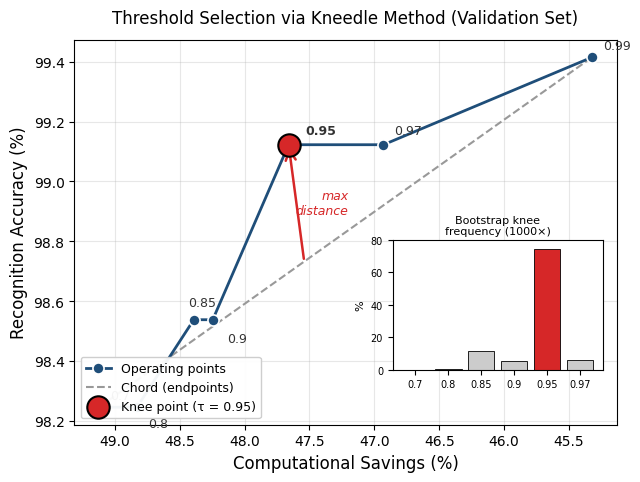

Kneedle figure saved.


In [ ]:
# ---- Figure: Threshold Kneedle (Figure X) ----
taus_kneedle = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
A_val_k, S_val_k = metrics_at(face_preds_val, hand_preds_val, y_val, taus_kneedle)

Sn = (S_val_k - S_val_k.min()) / (S_val_k.max() - S_val_k.min())
An = (A_val_k - A_val_k.min()) / (A_val_k.max() - A_val_k.min())
x1, y1 = Sn[0], An[0]; x2, y2 = Sn[-1], An[-1]
den = np.sqrt((y2-y1)**2 + (x2-x1)**2)
dists = [abs((y2-y1)*Sn[i]-(x2-x1)*An[i]+x2*y1-y2*x1)/den for i in range(len(taus_kneedle))]
knee_idx = int(np.argmax(dists))

from matplotlib.patches import FancyArrowPatch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(S_val_k, A_val_k, 'o-', color='#1f4e79', linewidth=2, markersize=8,
        markerfacecolor='#1f4e79', markeredgecolor='white', markeredgewidth=1.2, zorder=3,
        label='Operating points')
ax.plot([S_val_k[0], S_val_k[-1]], [A_val_k[0], A_val_k[-1]], '--',
        color='#999999', linewidth=1.5, zorder=2, label='Chord (endpoints)')
ax.scatter([S_val_k[knee_idx]], [A_val_k[knee_idx]], s=260,
           facecolor='#d62728', edgecolor='black', linewidth=1.5, zorder=5,
           label=f'Knee point (τ = {taus_kneedle[knee_idx]})')

px, py = S_val_k[knee_idx], A_val_k[knee_idx]
dx, dy = S_val_k[-1]-S_val_k[0], A_val_k[-1]-A_val_k[0]
t = ((px-S_val_k[0])*dx + (py-A_val_k[0])*dy) / (dx*dx + dy*dy)
fx, fy = S_val_k[0]+t*dx, A_val_k[0]+t*dy
arrow = FancyArrowPatch((fx, fy), (px, py), arrowstyle='->', color='#d62728',
                         linewidth=1.8, mutation_scale=18, zorder=4)
ax.add_patch(arrow)
ax.text((fx+px)/2-0.4, (fy+py)/2, 'max\ndistance',
        fontsize=9, color='#d62728', ha='right', va='center', style='italic')

label_offsets = {0.70:(8,6), 0.80:(8,-14), 0.85:(-4,10), 0.90:(10,-16),
                 0.95:(12,8), 0.97:(8,8), 0.99:(8,6)}
for i, tau in enumerate(taus_kneedle):
    xo, yo = label_offsets.get(tau, (8, 6))
    ax.annotate(f'{tau}', (S_val_k[i], A_val_k[i]),
                textcoords="offset points", xytext=(xo, yo),
                fontsize=9, color='#333333',
                fontweight='bold' if i == knee_idx else 'normal')

ax.set_xlabel('Computational Savings (%)', fontsize=12)
ax.set_ylabel('Recognition Accuracy (%)', fontsize=12)
ax.set_title('Threshold Selection via Kneedle Method (Validation Set)', fontsize=12, pad=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=9, framealpha=0.95)
ax.invert_xaxis()

# Bootstrap inset
boot_thr  = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97]
boot_freq = [knee_counts.get(t, 0)/10 for t in boot_thr]
inset = fig.add_axes([0.58, 0.22, 0.30, 0.26])
colors_bar = ['#d62728' if t == 0.95 else '#cccccc' for t in boot_thr]
inset.bar([str(t) for t in boot_thr], boot_freq, color=colors_bar,
          edgecolor='black', linewidth=0.6)
inset.set_title('Bootstrap knee\nfrequency (1000×)', fontsize=8, pad=4)
inset.set_ylabel('%', fontsize=8)
inset.tick_params(axis='both', labelsize=7)
inset.set_ylim(0, 80)

plt.savefig('/content/drive/MyDrive/Figure_Kneedle.png', dpi=300, bbox_inches='tight')
plt.show()
print("Kneedle figure saved.")

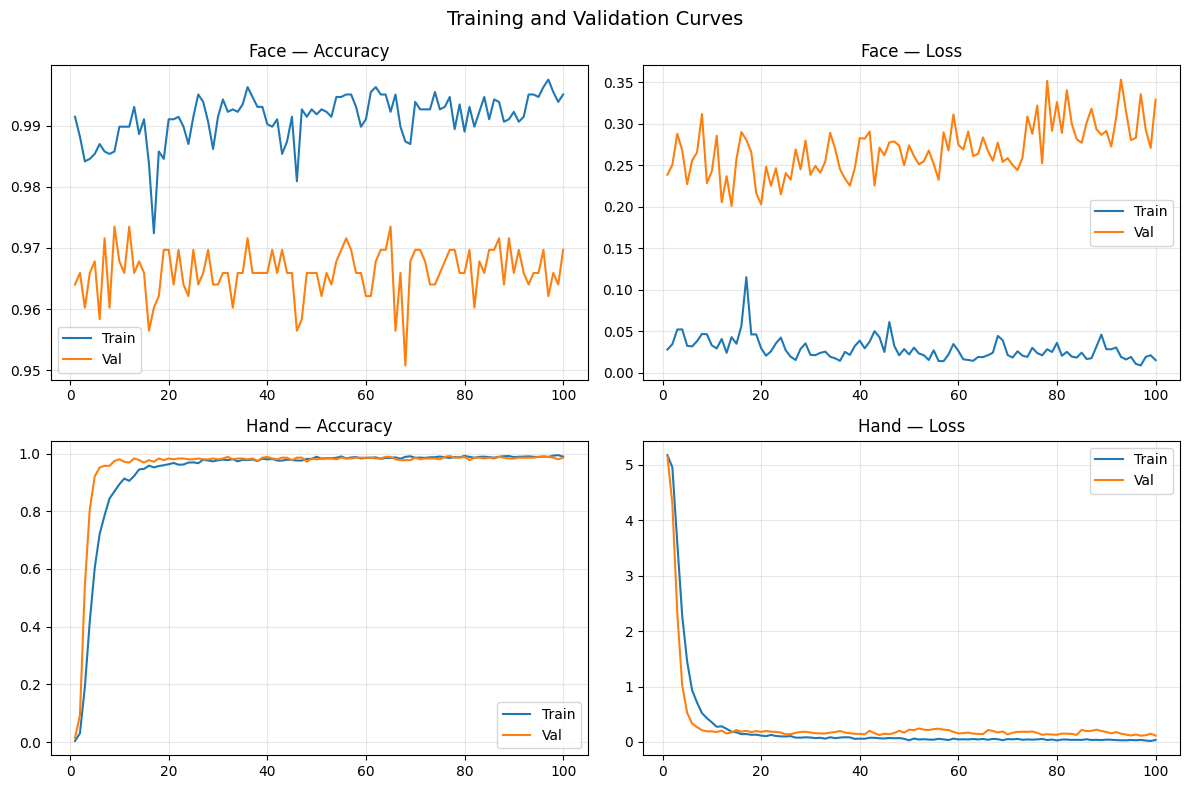

Figure 6 saved.


In [ ]:
# ---- Figure: Training Curves (Figure 6) ----
with open('/content/drive/MyDrive/history_face.json') as f:
    hist_face = json.load(f)
with open('/content/drive/MyDrive/history_palm_v2.json') as f:
    hist_hand = json.load(f)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
epochs = range(1, len(hist_face['accuracy']) + 1)

axes[0,0].plot(epochs, hist_face['accuracy'],     label='Train'); axes[0,0].plot(epochs, hist_face['val_accuracy'], label='Val')
axes[0,0].set_title('Face — Accuracy'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs, hist_face['loss'],     label='Train'); axes[0,1].plot(epochs, hist_face['val_loss'], label='Val')
axes[0,1].set_title('Face — Loss'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(epochs, hist_hand['accuracy'],     label='Train'); axes[1,0].plot(epochs, hist_hand['val_accuracy'], label='Val')
axes[1,0].set_title('Hand — Accuracy'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(epochs, hist_hand['loss'],     label='Train'); axes[1,1].plot(epochs, hist_hand['val_loss'], label='Val')
axes[1,1].set_title('Hand — Loss'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Training and Validation Curves', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Figure6_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

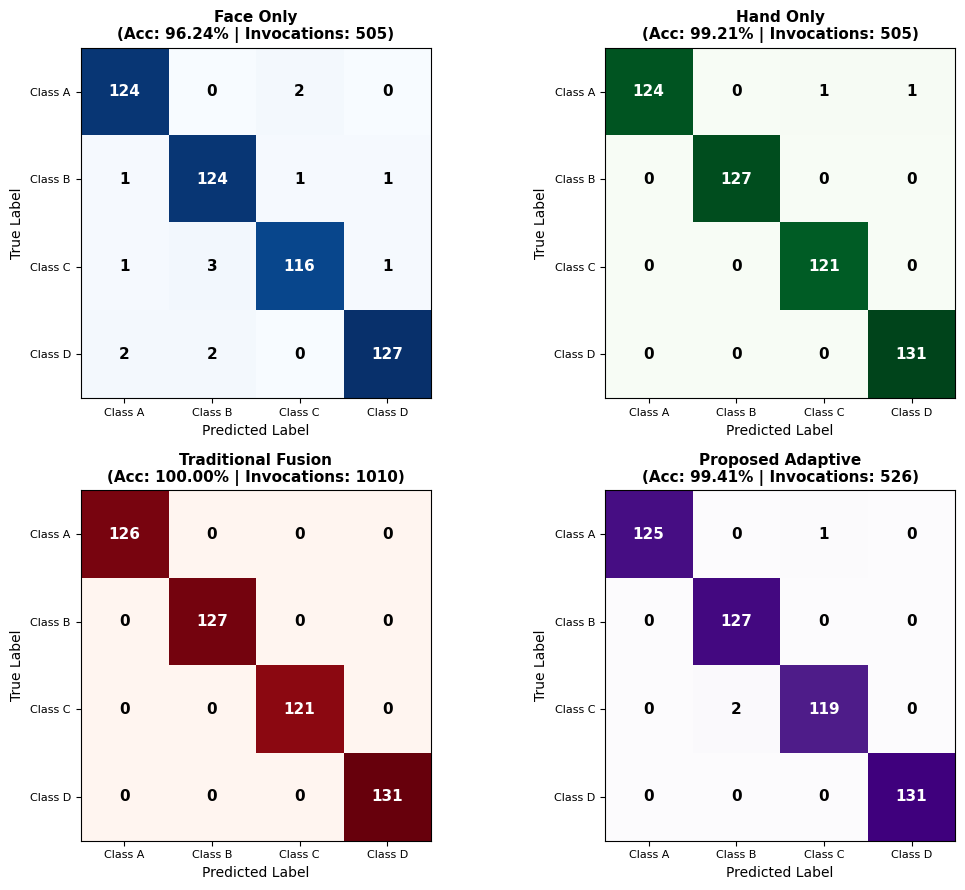

Figure 8 saved.


In [ ]:
# ---- Figure 8: Confusion matrices (four representative groups) ----
NG = 4
_edges = np.linspace(0, N_CLASSES, NG + 1).astype(int)
def _to_group(lbls):
    g = np.zeros_like(lbls)
    for gi in range(NG):
        g[(lbls >= _edges[gi]) & (lbls < _edges[gi + 1])] = gi
    return g
_yt_g = _to_group(y_true)
_glab = ['Class A', 'Class B', 'Class C', 'Class D']
_sys8 = [('Face Only', np.argmax(face_preds, 1), len(y_true), 'Blues'),
         ('Hand Only', np.argmax(hand_preds, 1), len(y_true), 'Greens'),
         ('Traditional Fusion', trad_preds, 2*len(y_true), 'Reds'),
         ('Proposed Adaptive', proposed_preds, len(y_true)+hand_invoked, 'Purples')]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, pred, inv, cmap) in zip(axes.flat, _sys8):
    acc = np.mean(pred == y_true) * 100
    cm = confusion_matrix(_yt_g, _to_group(pred), labels=range(NG))
    ax.imshow(cm, cmap=cmap)
    ax.set_title(f'{name}\n(Acc: {acc:.2f}% | Invocations: {inv})', fontsize=11, fontweight='bold')
    ax.set_xticks(range(NG)); ax.set_yticks(range(NG))
    ax.set_xticklabels(_glab, fontsize=8); ax.set_yticklabels(_glab, fontsize=8)
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
    thr = cm.max() / 2
    for r in range(NG):
        for c in range(NG):
            ax.text(c, r, cm[r, c], ha='center', va='center',
                    color='white' if cm[r, c] > thr else 'black', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Figure8_confusion.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

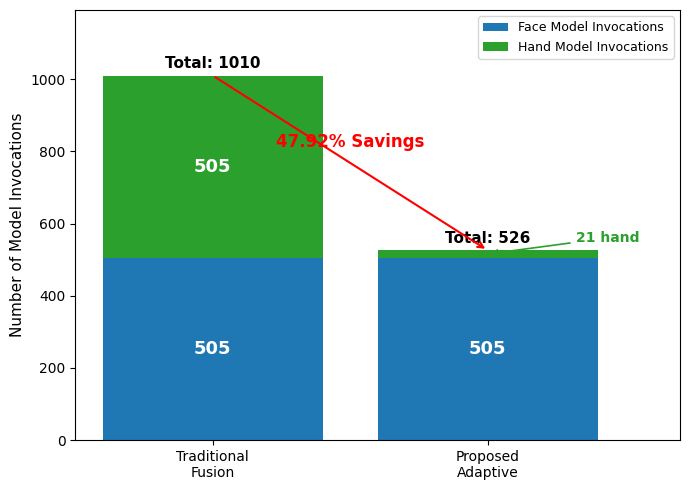

Figure 9 saved.


In [ ]:
# ---- Figure 9: Model invocation comparison ----
_n = len(y_true); _trad = 2 * _n; _prop = _n + hand_invoked
_sav = (1 - _prop / _trad) * 100
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar('Traditional\nFusion', _n, color='#1f77b4', label='Face Model Invocations')
ax.bar('Traditional\nFusion', _n, bottom=_n, color='#2ca02c', label='Hand Model Invocations')
ax.bar('Proposed\nAdaptive', _n, color='#1f77b4')
ax.bar('Proposed\nAdaptive', hand_invoked, bottom=_n, color='#2ca02c')
ax.text(0, _n/2, f'{_n}', ha='center', va='center', color='white', fontsize=13, fontweight='bold')
ax.text(0, _n+_n/2, f'{_n}', ha='center', va='center', color='white', fontsize=13, fontweight='bold')
ax.text(0, _trad+20, f'Total: {_trad}', ha='center', fontsize=11, fontweight='bold')
ax.text(1, _n/2, f'{_n}', ha='center', va='center', color='white', fontsize=13, fontweight='bold')
ax.annotate(f'{hand_invoked} hand', xy=(1.0, _n + hand_invoked/2), xytext=(1.32, _n + 55),
            ha='left', va='center', fontsize=10, fontweight='bold', color='#2ca02c',
            arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.2))
ax.text(1, _prop+20, f'Total: {_prop}', ha='center', fontsize=11, fontweight='bold')
ax.annotate('', xy=(1, _prop), xytext=(0, _trad), arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.text(0.5, (_trad+_prop)/2 + 45, f'{_sav:.2f}% Savings', ha='center', color='red', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Model Invocations', fontsize=11)
ax.set_ylim(0, _trad*1.18); ax.set_xlim(-0.5, 1.7)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Figure9_invocations.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

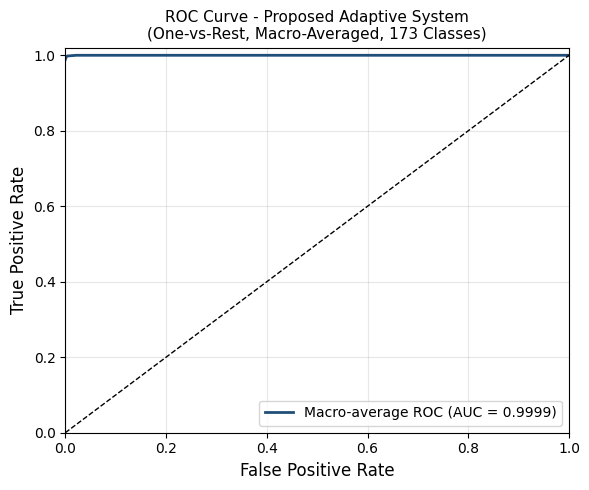

Figure 9 saved.


In [ ]:
# ---- Figure: ROC Curve (Figure 9) ----
# Macro-averaged one-vs-rest ROC over the classes present in the 505 clean pairs.
from sklearn.metrics import roc_curve, auc

classes_present = np.unique(y_true)                       # 173 present classes
y_bin_all = label_binarize(y_true, classes=np.arange(N_CLASSES))
present   = y_bin_all.sum(axis=0) > 0
yb = y_bin_all[:, present]
sc = proposed_scores[:, present]
n_present = yb.shape[1]

fpr_dict, tpr_dict, roc_dict = {}, {}, {}
for j in range(n_present):
    fpr_dict[j], tpr_dict[j], _ = roc_curve(yb[:, j], sc[:, j])
    roc_dict[j] = auc(fpr_dict[j], tpr_dict[j])

all_fpr  = np.unique(np.concatenate([fpr_dict[j] for j in range(n_present)]))
mean_tpr = np.zeros_like(all_fpr)
for j in range(n_present):
    mean_tpr += np.interp(all_fpr, fpr_dict[j], tpr_dict[j])
mean_tpr /= n_present
macro_auc = roc_auc_score(yb, sc, average='macro', multi_class='ovr')  # 0.9999 (matches paper)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(all_fpr, mean_tpr, color='#1f4e79', linewidth=2,
        label=f'Macro-average ROC (AUC = {macro_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Proposed Adaptive System\n'
             f'(One-vs-Rest, Macro-Averaged, {n_present} Classes)', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Figure9_ROC.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

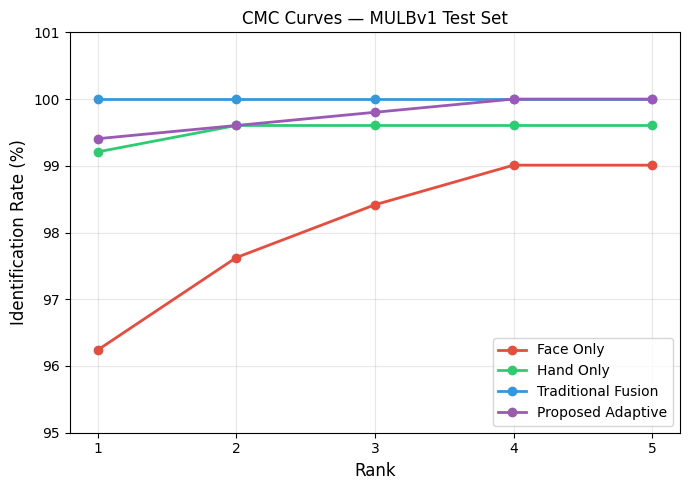

Figure 10 saved.


In [ ]:
# ---- Figure: CMC Curves (Figure 10) ----
systems_cmc = [
    ("Face Only",          face_preds),
    ("Hand Only",          hand_preds),
    ("Traditional Fusion", face_preds * hand_preds),
    ("Proposed Adaptive",  proposed_scores),
]
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

fig, ax = plt.subplots(figsize=(7, 5))
for (name, scores), color in zip(systems_cmc, colors):
    cmc = [rank_n(scores, y_true, r) for r in range(1, 6)]
    ax.plot(range(1, 6), cmc, 'o-', label=name, color=color, linewidth=2, markersize=6)

ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('Identification Rate (%)', fontsize=12)
ax.set_title('CMC Curves — MULBv1 Test Set', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 6))
ax.set_ylim([95, 101])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Figure10_CMC.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/exclude_list.csv'))

True


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/exclude_list.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Matched-Pair Construction and Excluded-Subject Report
# ============================================================
import os
import glob as gb
import hashlib

# Path definitions
FACE_TRAIN_DIR = '/content/drive/MyDrive/split faces/train'
FACE_TEST_DIR  = '/content/drive/MyDrive/split faces/test'
HAND_TRAIN_DIR = '/content/drive/MyDrive/final split hand/train'
HAND_TEST_DIR  = '/content/drive/MyDrive/final split hand/test'

# Subject list
Code = {c.lower().strip(): i for i, c in enumerate(sorted(os.listdir(FACE_TEST_DIR)))
        if os.path.isdir(os.path.join(FACE_TEST_DIR, c))}

def sha256_of(path):
    with open(path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()

def clean_counts_per_subject(test_dir, train_dir, code):
    train_hashes = set()
    for folder in os.listdir(train_dir):
        fp = os.path.join(train_dir, folder)
        if not os.path.isdir(fp):
            continue
        for f in gb.glob(os.path.join(fp, '*.jpg')):
            train_hashes.add(sha256_of(f))

    counts = {}
    for folder in sorted(os.listdir(test_dir)):
        fp = os.path.join(test_dir, folder)
        if not os.path.isdir(fp):
            continue
        key = folder.lower().strip()
        if key not in code:
            continue
        seen, clean = set(), 0
        for f in gb.glob(os.path.join(fp, '*.jpg')):
            h = sha256_of(f)
            if h not in train_hashes and h not in seen:
                clean += 1
                seen.add(h)
        counts[key] = clean
    return counts

face_counts = clean_counts_per_subject(FACE_TEST_DIR, FACE_TRAIN_DIR, Code)
hand_counts = clean_counts_per_subject(HAND_TEST_DIR, HAND_TRAIN_DIR, Code)

total_pairs, with_pairs, excluded = 0, 0, []
for subj in Code:
    f = face_counts.get(subj, 0)
    h = hand_counts.get(subj, 0)
    p = min(f, h)
    total_pairs += p
    if p > 0:
        with_pairs += 1
    else:
        excluded.append((subj, f, h))

print("=" * 60)
print("Matched-Pair Construction (clean evaluation set)")
print("=" * 60)
print(f"Clean face images  : {sum(face_counts.values())}")
print(f"Clean hand images  : {sum(hand_counts.values())}")
print(f"Matched pairs      : {total_pairs}")
print(f"Subjects paired    : {with_pairs} / {len(Code)}")
print(f"Subjects excluded  : {len(excluded)}")
print("-" * 60)
print("Excluded subjects (no complete cross-modal pair):")
for subj, f, h in excluded:
    print(f"  {subj:<20} face={f}  hand={h}")
print("=" * 60)

Matched-Pair Construction (clean evaluation set)
Clean face images  : 521
Clean hand images  : 511
Matched pairs      : 505
Subjects paired    : 173 / 176
Subjects excluded  : 3
------------------------------------------------------------
Excluded subjects (no complete cross-modal pair):
  ali fadhel           face=0  hand=3
  muheman majeed       face=3  hand=0
  mustafa fathel       face=3  hand=0


In [ ]:
import os
import glob as gb
import hashlib

def sha256_of(path):
    with open(path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()

FACE_TRAIN_DIR = '/content/drive/MyDrive/split faces/train'
FACE_VAL_DIR   = '/content/drive/MyDrive/split faces/val'
HAND_TRAIN_DIR = '/content/drive/MyDrive/final split hand/train'
HAND_VAL_DIR   = '/content/drive/MyDrive/final split hand/val'

Code = {c.lower().strip(): i for i, c in enumerate(sorted(os.listdir(FACE_VAL_DIR)))
        if os.path.isdir(os.path.join(FACE_VAL_DIR, c))}

def clean_counts(val_dir, train_dir, code, cap=None):
    train_hashes = set()
    for folder in os.listdir(train_dir):
        fp = os.path.join(train_dir, folder)
        if not os.path.isdir(fp): continue
        for f in gb.glob(os.path.join(fp, '*.jpg')):
            train_hashes.add(sha256_of(f))
    counts = {}
    for folder in sorted(os.listdir(val_dir)):
        fp = os.path.join(val_dir, folder)
        if not os.path.isdir(fp): continue
        key = folder.lower().strip()
        if key not in code: continue
        seen, clean = set(), 0
        for f in gb.glob(os.path.join(fp, '*.jpg')):
            h = sha256_of(f)
            if h not in train_hashes and h not in seen:
                clean += 1
                seen.add(h)
        counts[key] = min(clean, cap) if cap else clean
    return counts

# With cap of 2 images per subject
face_val = clean_counts(FACE_VAL_DIR, FACE_TRAIN_DIR, Code, cap=2)
hand_val = clean_counts(HAND_VAL_DIR, HAND_TRAIN_DIR, Code, cap=2)

total_pairs, with_pairs, excluded = 0, 0, []
for subj in Code:
    f = face_val.get(subj, 0)
    h = hand_val.get(subj, 0)
    p = min(f, h)
    total_pairs += p
    if p > 0:
        with_pairs += 1
    else:
        excluded.append((subj, f, h))

print(f"Validation matched pairs (cap=2): {total_pairs}")
print(f"Subjects with pairs: {with_pairs}/176")
print(f"Subjects excluded: {len(excluded)}")
print()
print("Subjects with < 2 pairs:")
for subj in Code:
    f = face_val.get(subj, 0)
    h = hand_val.get(subj, 0)
    p = min(f, h)
    if p < 2:
        print(f"  {subj:<20} face={f} hand={h} pairs={p}")

Validation matched pairs (cap=2): 343
Subjects with pairs: 173/176
Subjects excluded: 3

Subjects with < 2 pairs:
  ali fadhel           face=1 hand=2 pairs=1
  atheer saad          face=2 hand=1 pairs=1
  kaher musa           face=2 hand=0 pairs=0
  karar ali            face=2 hand=1 pairs=1
  muheman majeed       face=2 hand=0 pairs=0
  mustafa fathel       face=2 hand=0 pairs=0


In [ ]:
def load_val_pairs_original(face_dir, hand_dir, face_train, hand_train, code):
    """Replicate the original validation pairing: take first 2 clean images
    per subject for each modality, then pair by min."""

    def clean_files(vdir, tdir, code, cap=2):
        train_h = set()
        for folder in os.listdir(tdir):
            fp = os.path.join(tdir, folder)
            if not os.path.isdir(fp): continue
            for f in gb.glob(os.path.join(fp, '*.jpg')):
                train_h.add(sha256_of(f))
        result = {}
        for folder in sorted(os.listdir(vdir)):
            fp = os.path.join(vdir, folder)
            if not os.path.isdir(fp): continue
            key = folder.lower().strip()
            if key not in code: continue
            seen, files = set(), []
            for f in sorted(gb.glob(os.path.join(fp, '*.jpg'))):
                h = sha256_of(f)
                if h not in train_h and h not in seen:
                    files.append(f)
                    seen.add(h)
                if len(files) >= cap:
                    break
            result[key] = len(files)
        return result

    fc = clean_files(face_dir, face_train, code)
    hc = clean_files(hand_dir, hand_train, code)

    total = sum(min(fc.get(s,0), hc.get(s,0)) for s in code)
    return total, fc, hc

total, fc, hc = load_val_pairs_original(FACE_VAL_DIR, HAND_VAL_DIR,
                                         FACE_TRAIN_DIR, HAND_TRAIN_DIR, Code)
print(f"Validation pairs (original method): {total}")

Validation pairs (original method): 343


In [ ]:
# Check what number the actual threshold-selection code used
# Load validation predictions the same way the paper did
import numpy as np
import tensorflow as tf

face_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/face_model_final_fixedfeb.keras', compile=False)
hand_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/hand_model_final_v2.keras', compile=False)

import cv2
IMG = 200
def load_capped(vdir, tdir, code, cap=2):
    train_h = set()
    for folder in os.listdir(tdir):
        fp = os.path.join(tdir, folder)
        if not os.path.isdir(fp): continue
        for f in gb.glob(os.path.join(fp, '*.jpg')):
            train_h.add(sha256_of(f))
    X, Y = [], []
    for folder in sorted(os.listdir(vdir)):
        fp = os.path.join(vdir, folder)
        if not os.path.isdir(fp): continue
        key = folder.lower().strip()
        if key not in code: continue
        seen, cnt = set(), 0
        for f in sorted(gb.glob(os.path.join(fp, '*.jpg'))):
            h = sha256_of(f)
            if h not in train_h and h not in seen:
                img = cv2.imread(f)
                img = cv2.resize(img, (IMG, IMG))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)/255.0
                X.append(img); Y.append(code[key])
                seen.add(h); cnt += 1
            if cnt >= cap: break
    return np.array(X), np.array(Y)

xf, yf = load_capped(FACE_VAL_DIR, FACE_TRAIN_DIR, Code)
xh, yh = load_capped(HAND_VAL_DIR, HAND_TRAIN_DIR, Code)
print(f"Face val images: {len(xf)}")
print(f"Hand val images: {len(xh)}")

# Align by taking min per subject
xf = np.expand_dims(xf, -1)
xh = np.expand_dims(xh, -1)
fp = face_model.predict(xf, batch_size=32, verbose=0)
hp = hand_model.predict(xh, batch_size=32, verbose=0)

# Pair by subject
from collections import defaultdict
face_by_subj = defaultdict(list)
hand_by_subj = defaultdict(list)
for i, y in enumerate(yf): face_by_subj[y].append(fp[i])
for i, y in enumerate(yh): hand_by_subj[y].append(hp[i])

pairs_f, pairs_h, pairs_y = [], [], []
for subj in Code.values():
    nf = len(face_by_subj[subj])
    nh = len(hand_by_subj[subj])
    for k in range(min(nf, nh)):
        pairs_f.append(face_by_subj[subj][k])
        pairs_h.append(hand_by_subj[subj][k])
        pairs_y.append(subj)

pairs_f = np.array(pairs_f)
pairs_h = np.array(pairs_h)
pairs_y = np.array(pairs_y)
print(f"Total validation pairs: {len(pairs_y)}")

# Accuracy at tau=0.95
conf = np.max(pairs_f, axis=1)
cls = np.argmax(pairs_f, axis=1)
fused = 0.5*pairs_f + 0.5*pairs_h
pred = np.where(conf >= 0.95, cls, np.argmax(fused, axis=1))
acc = np.mean(pred == pairs_y) * 100
print(f"Validation accuracy @0.95: {acc:.2f}%")

Face val images: 351
Hand val images: 344
Total validation pairs: 343
Validation accuracy @0.95: 99.13%


In [ ]:
taus = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]

conf = np.max(pairs_f, axis=1)
cls = np.argmax(pairs_f, axis=1)
fused = 0.5*pairs_f + 0.5*pairs_h
n = len(pairs_y)

print(f"Validation pairs: {n}")
print(f"{'tau':>6} {'Accuracy':>10} {'Savings':>10}")
print("-" * 30)
for tau in taus:
    pred = np.where(conf >= tau, cls, np.argmax(fused, axis=1))
    acc = np.mean(pred == pairs_y) * 100
    inv = np.sum(conf < tau)
    sav = (1 - (n + inv) / (2 * n)) * 100
    print(f"{tau:>6} {acc:>9.2f}% {sav:>9.2f}%")

Validation pairs: 343
   tau   Accuracy    Savings
------------------------------
   0.7     98.25%     49.13%
   0.8     98.25%     48.83%
  0.85     98.54%     48.40%
   0.9     98.54%     48.25%
  0.95     99.13%     47.67%
  0.97     99.13%     46.94%
  0.99     99.42%     45.34%


In [ ]:
def kneedle(A, S, taus):
    if S.max() == S.min() or A.max() == A.min():
        return None
    Sn = (S - S.min()) / (S.max() - S.min())
    An = (A - A.min()) / (A.max() - A.min())
    x1, y1 = Sn[0], An[0]; x2, y2 = Sn[-1], An[-1]
    den = np.sqrt((y2-y1)**2 + (x2-x1)**2)
    dists = [abs((y2-y1)*Sn[i]-(x2-x1)*An[i]+x2*y1-y2*x1)/den for i in range(len(taus))]
    return taus[np.argmax(dists)]

def metrics_at(fp, hp, yt, taus):
    fc = np.max(fp, axis=1)
    fcl = np.argmax(fp, axis=1)
    fus = np.argmax(0.5*fp + 0.5*hp, axis=1)
    n = len(yt)
    A, S = [], []
    for tau in taus:
        pred = np.where(fc >= tau, fcl, fus)
        A.append(np.mean(pred == yt) * 100)
        inv = np.sum(fc < tau)
        S.append((1 - (n + inv) / (2 * n)) * 100)
    return np.array(A), np.array(S)

taus = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
N = len(pairs_y)
knee_counts = {}
np.random.seed(42)
for _ in range(1000):
    idx = np.random.choice(N, N, replace=True)
    A, S = metrics_at(pairs_f[idx], pairs_h[idx], pairs_y[idx], taus)
    k = kneedle(A, S, taus)
    knee_counts[k] = knee_counts.get(k, 0) + 1

print("Bootstrap knee frequency (343 pairs, 1000 resamples):")
for tau in sorted(k for k in knee_counts if k is not None):
    print(f"  tau={tau}: {knee_counts[tau]/10:.1f}%")

# Alpha range
alphas_95 = []
A_val, S_val = metrics_at(pairs_f, pairs_h, pairs_y, taus)
for alpha in np.arange(0.50, 1.001, 0.005):
    U = alpha * A_val + (1 - alpha) * S_val
    if taus[np.argmax(U)] == 0.95:
        alphas_95.append(alpha)
if alphas_95:
    print(f"\nAlpha range for tau=0.95: [{min(alphas_95):.2f}, {max(alphas_95):.2f}]")

# Test accuracy
print(f"\nTest accuracy @0.95: 99.41% (unchanged - test set is 505)")

Bootstrap knee frequency (343 pairs, 1000 resamples):
  tau=0.8: 1.3%
  tau=0.85: 11.0%
  tau=0.9: 6.0%
  tau=0.95: 74.0%
  tau=0.97: 5.7%

Alpha range for tau=0.95: [0.63, 0.89]

Test accuracy @0.95: 99.41% (unchanged - test set is 505)


In [ ]:
# ============================================================
# Validation-Set Matched-Pair Construction (two-per-subject cap)
# ============================================================
import os
import glob as gb
import hashlib

FACE_TRAIN_DIR = '/content/drive/MyDrive/split faces/train'
FACE_VAL_DIR   = '/content/drive/MyDrive/split faces/val'
HAND_TRAIN_DIR = '/content/drive/MyDrive/final split hand/train'
HAND_VAL_DIR   = '/content/drive/MyDrive/final split hand/val'

Code = {c.lower().strip(): i for i, c in enumerate(sorted(os.listdir(FACE_VAL_DIR)))
        if os.path.isdir(os.path.join(FACE_VAL_DIR, c))}

def sha256_of(path):
    with open(path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()

def clean_count_capped(val_dir, train_dir, code, cap=2):
    train_hashes = set()
    for folder in os.listdir(train_dir):
        fp = os.path.join(train_dir, folder)
        if not os.path.isdir(fp):
            continue
        for f in gb.glob(os.path.join(fp, '*.jpg')):
            train_hashes.add(sha256_of(f))

    counts = {}
    for folder in sorted(os.listdir(val_dir)):
        fp = os.path.join(val_dir, folder)
        if not os.path.isdir(fp):
            continue
        key = folder.lower().strip()
        if key not in code:
            continue
        seen, cnt = set(), 0
        for f in sorted(gb.glob(os.path.join(fp, '*.jpg'))):
            h = sha256_of(f)
            if h not in train_hashes and h not in seen:
                cnt += 1
                seen.add(h)
            if cnt >= cap:
                break
        counts[key] = cnt
    return counts

CAP = 2
face_val = clean_count_capped(FACE_VAL_DIR, FACE_TRAIN_DIR, Code, CAP)
hand_val = clean_count_capped(HAND_VAL_DIR, HAND_TRAIN_DIR, Code, CAP)

total_pairs, paired, shortfall_rows = 0, 0, []
for subj in Code:
    f = face_val.get(subj, 0)
    h = hand_val.get(subj, 0)
    p = min(f, h)
    total_pairs += p
    if p > 0:
        paired += 1
    if p < CAP:
        shortfall_rows.append((subj, f, h, p, CAP - p))

max_pairs = CAP * len(Code)
print("=" * 62)
print("Validation Matched-Pair Construction (cap = 2 per subject)")
print("=" * 62)
print(f"Theoretical maximum : {CAP} x {len(Code)} = {max_pairs}")
print(f"Clean face images   : {sum(face_val.values())}")
print(f"Clean hand images   : {sum(hand_val.values())}")
print(f"Matched pairs       : {total_pairs}")
print(f"Subjects paired     : {paired} / {len(Code)}")
print("-" * 62)
print(f"{'Subject':<20}{'Face':>6}{'Hand':>6}{'Pairs':>7}{'Shortfall':>11}")
print("-" * 62)
for subj, f, h, p, s in shortfall_rows:
    print(f"{subj:<20}{f:>6}{h:>6}{p:>7}{-s:>11}")
total_short = sum(s for *_, s in shortfall_rows)
print("-" * 62)
print(f"Total shortfall vs maximum : {total_short}")
print(f"{max_pairs} - {total_short} = {max_pairs - total_short} matched pairs")
print("=" * 62)

Validation Matched-Pair Construction (cap = 2 per subject)
Theoretical maximum : 2 x 176 = 352
Clean face images   : 351
Clean hand images   : 344
Matched pairs       : 343
Subjects paired     : 173 / 176
--------------------------------------------------------------
Subject               Face  Hand  Pairs  Shortfall
--------------------------------------------------------------
ali fadhel               1     2      1         -1
atheer saad              2     1      1         -1
kaher musa               2     0      0         -2
karar ali                2     1      1         -1
muheman majeed           2     0      0         -2
mustafa fathel           2     0      0         -2
--------------------------------------------------------------
Total shortfall vs maximum : 9
352 - 9 = 343 matched pairs


In [ ]:
import os, glob as gb, cv2, hashlib
import numpy as np
import tensorflow as tf

IMG = 200
FACE_TRAIN = '/content/drive/MyDrive/split faces/train'
FACE_TEST  = '/content/drive/MyDrive/split faces/test'
HAND_TRAIN = '/content/drive/MyDrive/final split hand/train'
HAND_TEST  = '/content/drive/MyDrive/final split hand/test'

Code = {c.lower().strip(): i for i, c in enumerate(sorted(os.listdir(FACE_TEST)))
        if os.path.isdir(os.path.join(FACE_TEST, c))}

def sha256_of(p):
    with open(p,'rb') as f: return hashlib.sha256(f.read()).hexdigest()

def load_clean(test_dir, train_dir, code):
    train_h = set()
    for folder in os.listdir(train_dir):
        fp = os.path.join(train_dir, folder)
        if not os.path.isdir(fp): continue
        for f in gb.glob(os.path.join(fp,'*.jpg')): train_h.add(sha256_of(f))
    imgs_by_subj = {}
    for folder in sorted(os.listdir(test_dir)):
        fp = os.path.join(test_dir, folder)
        if not os.path.isdir(fp): continue
        key = folder.lower().strip()
        if key not in code: continue
        seen, lst = set(), []
        for f in sorted(gb.glob(os.path.join(fp,'*.jpg'))):
            h = sha256_of(f)
            if h not in train_h and h not in seen:
                img = cv2.imread(f)
                img = cv2.resize(img,(IMG,IMG))
                img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY).astype(np.float32)/255.0
                lst.append(img); seen.add(h)
        imgs_by_subj[key] = lst
    return imgs_by_subj

face_model = tf.keras.models.load_model('/content/drive/MyDrive/face_model_final_fixedfeb.keras', compile=False)
hand_model = tf.keras.models.load_model('/content/drive/MyDrive/hand_model_final_v2.keras', compile=False)

face_imgs = load_clean(FACE_TEST, FACE_TRAIN, Code)
hand_imgs = load_clean(HAND_TEST, HAND_TRAIN, Code)

# Build 505 matched pairs
pf, ph, py = [], [], []
for subj, sid in Code.items():
    nf = len(face_imgs.get(subj, []))
    nh = len(hand_imgs.get(subj, []))
    for k in range(min(nf, nh)):
        pf.append(face_imgs[subj][k])
        ph.append(hand_imgs[subj][k])
        py.append(sid)

pf = np.expand_dims(np.array(pf), -1)
ph = np.expand_dims(np.array(ph), -1)
py = np.array(py)
print(f"Pairs: {len(py)}")

face_preds = face_model.predict(pf, batch_size=32, verbose=0)
hand_preds = hand_model.predict(ph, batch_size=32, verbose=0)
y_true = py

# Now analyze the 5 boundary cases
face_conf = np.max(face_preds, axis=1)
face_pred = np.argmax(face_preds, axis=1)
fused = 0.5 * face_preds + 0.5 * hand_preds
fused_pred = np.argmax(fused, axis=1)

mask_new = (face_conf >= 0.95) & (face_conf < 0.97)
idx_new = np.where(mask_new)[0]
print(f"Cases with 0.95 <= conf < 0.97: {len(idx_new)}\n")

corrected = broken = stayed_correct = stayed_wrong = 0
print(f"{'Idx':>5} {'True':>6} {'Face':>6} {'Fuse':>6} {'FaceOK':>7} {'FuseOK':>7} {'Effect':>14}")
print("-"*62)
for i in idx_new:
    fok = (face_pred[i] == y_true[i])
    uok = (fused_pred[i] == y_true[i])
    if not fok and uok: eff="CORRECTED"; corrected+=1
    elif fok and not uok: eff="BROKEN"; broken+=1
    elif fok and uok: eff="stays correct"; stayed_correct+=1
    else: eff="stays wrong"; stayed_wrong+=1
    print(f"{i:>5} {y_true[i]:>6} {face_pred[i]:>6} {fused_pred[i]:>6} {str(fok):>7} {str(uok):>7} {eff:>14}")

print("-"*62)
print(f"Corrected: {corrected} | Broken: {broken} | Stays correct: {stayed_correct} | Stays wrong: {stayed_wrong}")
print(f"Net change: +{corrected-broken}")
print(f"\nTEXT SAYS: 1 corrected, 4 already correct")
print(f"ACTUAL: {corrected} corrected, {stayed_correct} already correct, {broken} broken, {stayed_wrong} stayed wrong")

Pairs: 505
Cases with 0.95 <= conf < 0.97: 5

  Idx   True   Face   Fuse  FaceOK  FuseOK         Effect
--------------------------------------------------------------
   50     16     16     16    True    True  stays correct
   93     32     32     32    True    True  stays correct
  117     41    117     41   False    True      CORRECTED
  310    108    108    108    True    True  stays correct
  354    124    124    124    True    True  stays correct
--------------------------------------------------------------
Corrected: 1 | Broken: 0 | Stays correct: 4 | Stays wrong: 0
Net change: +1

TEXT SAYS: 1 corrected, 4 already correct
ACTUAL: 1 corrected, 4 already correct, 0 broken, 0 stayed wrong


In [ ]:
# ============================================================
# Boundary-Case Analysis: tau = 0.95 vs tau = 0.97  (self-contained)
# ============================================================
# Isolates the probes with 0.95 <= face_confidence < 0.97 (accepted on
# the face model at tau=0.95, routed to hand fusion at tau=0.97) and
# reports, for each, whether fusion changed the outcome. Confirms that
# exactly one case is genuinely corrected, accounting for the
# 99.41% -> 99.60% accuracy change in Table 4.

import os, glob as gb, cv2, hashlib
import numpy as np
import tensorflow as tf

IMG = 200
FACE_TRAIN = '/content/drive/MyDrive/split faces/train'
FACE_TEST  = '/content/drive/MyDrive/split faces/test'
HAND_TRAIN = '/content/drive/MyDrive/final split hand/train'
HAND_TEST  = '/content/drive/MyDrive/final split hand/test'

Code = {c.lower().strip(): i for i, c in enumerate(sorted(os.listdir(FACE_TEST)))
        if os.path.isdir(os.path.join(FACE_TEST, c))}

def sha256_of(p):
    with open(p, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()

def load_clean(test_dir, train_dir, code):
    """Load deduplicated test images per subject (grayscale, 200x200, /255)."""
    train_h = set()
    for folder in os.listdir(train_dir):
        fp = os.path.join(train_dir, folder)
        if not os.path.isdir(fp):
            continue
        for f in gb.glob(os.path.join(fp, '*.jpg')):
            train_h.add(sha256_of(f))
    by_subj = {}
    for folder in sorted(os.listdir(test_dir)):
        fp = os.path.join(test_dir, folder)
        if not os.path.isdir(fp):
            continue
        key = folder.lower().strip()
        if key not in code:
            continue
        seen, lst = set(), []
        for f in sorted(gb.glob(os.path.join(fp, '*.jpg'))):
            h = sha256_of(f)
            if h not in train_h and h not in seen:
                img = cv2.imread(f)
                img = cv2.resize(img, (IMG, IMG))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
                lst.append(img)
                seen.add(h)
        by_subj[key] = lst
    return by_subj

# Load models and clean test images
face_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/face_model_final_fixedfeb.keras', compile=False)
hand_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/hand_model_final_v2.keras', compile=False)

face_imgs = load_clean(FACE_TEST, FACE_TRAIN, Code)
hand_imgs = load_clean(HAND_TEST, HAND_TRAIN, Code)

# Build the 505 matched pairs (k-th face with k-th hand per subject)
pf, ph, py = [], [], []
for subj, sid in Code.items():
    n = min(len(face_imgs.get(subj, [])), len(hand_imgs.get(subj, [])))
    for k in range(n):
        pf.append(face_imgs[subj][k])
        ph.append(hand_imgs[subj][k])
        py.append(sid)

pf = np.expand_dims(np.array(pf), -1)
ph = np.expand_dims(np.array(ph), -1)
y_true = np.array(py)

face_preds = face_model.predict(pf, batch_size=32, verbose=0)
hand_preds = hand_model.predict(ph, batch_size=32, verbose=0)
print(f"Matched test pairs: {len(y_true)}\n")

# ---- Boundary-case analysis ----
face_conf  = np.max(face_preds, axis=1)
face_pred  = np.argmax(face_preds, axis=1)
fused_pred = np.argmax(0.5 * face_preds + 0.5 * hand_preds, axis=1)

mask = (face_conf >= 0.95) & (face_conf < 0.97)
idx  = np.where(mask)[0]

print("=" * 66)
print(f"Boundary cases with 0.95 <= face confidence < 0.97: {len(idx)}")
print("=" * 66)
print(f"{'Idx':>5} {'TrueID':>7} {'FacePred':>9} {'FusePred':>9} "
      f"{'FaceOK':>7} {'FuseOK':>7} {'Effect':>14}")
print("-" * 66)

corrected = broken = stay_ok = stay_wrong = 0
for i in idx:
    face_ok = (face_pred[i]  == y_true[i])
    fuse_ok = (fused_pred[i] == y_true[i])
    if   not face_ok and fuse_ok: effect = "CORRECTED";     corrected  += 1
    elif face_ok and not fuse_ok: effect = "BROKEN";        broken     += 1
    elif face_ok and fuse_ok:     effect = "stays correct"; stay_ok    += 1
    else:                         effect = "stays wrong";   stay_wrong += 1
    print(f"{i:>5} {y_true[i]:>7} {face_pred[i]:>9} {fused_pred[i]:>9} "
          f"{str(face_ok):>7} {str(fuse_ok):>7} {effect:>14}")

print("-" * 66)
print(f"Corrected by fusion : {corrected}")
print(f"Broken by fusion    : {broken}")
print(f"Already correct     : {stay_ok}")
print(f"Still wrong         : {stay_wrong}")
print(f"Net accuracy change : +{corrected - broken} case(s)")
print("=" * 66)

acc_095 = np.mean(np.where(face_conf >= 0.95, face_pred, fused_pred) == y_true) * 100
acc_097 = np.mean(np.where(face_conf >= 0.97, face_pred, fused_pred) == y_true) * 100
print(f"Accuracy at tau=0.95 : {acc_095:.2f}%  "
      f"(errors = {int(round((100-acc_095)/100*len(y_true)))})")
print(f"Accuracy at tau=0.97 : {acc_097:.2f}%  "
      f"(errors = {int(round((100-acc_097)/100*len(y_true)))})")
print(f"Improvement          : {acc_097-acc_095:.2f} pp "
      f"= {corrected} corrected - {broken} broken")

Matched test pairs: 505

Boundary cases with 0.95 <= face confidence < 0.97: 5
  Idx  TrueID  FacePred  FusePred  FaceOK  FuseOK         Effect
------------------------------------------------------------------
   50      16        16        16    True    True  stays correct
   93      32        32        32    True    True  stays correct
  117      41       117        41   False    True      CORRECTED
  310     108       108       108    True    True  stays correct
  354     124       124       124    True    True  stays correct
------------------------------------------------------------------
Corrected by fusion : 1
Broken by fusion    : 0
Already correct     : 4
Still wrong         : 0
Net accuracy change : +1 case(s)
Accuracy at tau=0.95 : 99.41%  (errors = 3)
Accuracy at tau=0.97 : 99.60%  (errors = 2)
Improvement          : 0.20 pp = 1 corrected - 0 broken
